In [1]:
%load_ext autoreload
%autoreload 2

import risk_kit as rk
import numpy as np
import pandas as pd

In [2]:
ind_rets = rk.get_ind_returns()
tmi_return = rk.get_total_market_index_returns()

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',
C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


In [3]:
risky_r = ind_rets.loc['2000':][['Steel', 'Fin', 'Beer']]
safe_r = pd.DataFrame().reindex_like(risky_r)

In [4]:
safe_r[:] = 0.03/12
start = 1000
floor = 0.8

1. cushion - (asset val - floor value)
2. compute an allocation to safe and risky assets --> m * risky budget
3. recompute the asset value based on the returns

In [5]:
def compound1(r):
    return(1 + r).prod() - 1
def compound2(r):
    return np.expm1(np.log1p(r).sum())

In [6]:
compound1(risky_r)

Steel   -0.051696
Fin      1.773937
Beer     3.361349
dtype: float64

In [7]:
compound2(risky_r)

Steel   -0.051696
Fin      1.773937
Beer     3.361349
dtype: float64

In [8]:
%timeit compound1(risky_r)

192 μs ± 932 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [9]:
%timeit compound2(risky_r)

179 μs ± 802 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [10]:
dates = risky_r.index
n_steps = len(risky_r)
account_val = start
floor_val = start * floor
m = 3 

In [11]:
account_history = pd.DataFrame().reindex_like(risky_r)
cushion_history = pd.DataFrame().reindex_like(risky_r)
risky_w_history = pd.DataFrame().reindex_like(risky_r)

In [14]:
for step in range(n_steps):
    cushion = (account_val - floor_val) / account_val
    risky_w = cushion * m 
    risky_w = np.minimum(risky_w, 1)
    risky_w = np.maximum(risky_w, 0)
    safe_w = 1 - risky_w
    risky_alloc = account_val * risky_w
    safe_alloc = account_val * safe_w
    ## update the account val for this step
    account_val = risky_alloc * (1 + risky_r.iloc[step]) + safe_alloc * (1 + safe_r.iloc[step])
    cushion_history.iloc[step] = cushion
    risky_w_history.iloc[step] = risky_w
    account_history.iloc[step] = account_val

In [15]:
account_history.head()

,Steel,Fin,Beer
2000-01,984.380000,974.480000,987.320000
2000-02,1023.292876,931.167544,922.971256
2000-03,1047.555176,998.187296,924.835988
2000-04,1042.079009,973.927479,939.993701
2000-05,1007.137753,1001.460033,991.145489


<Axes: >

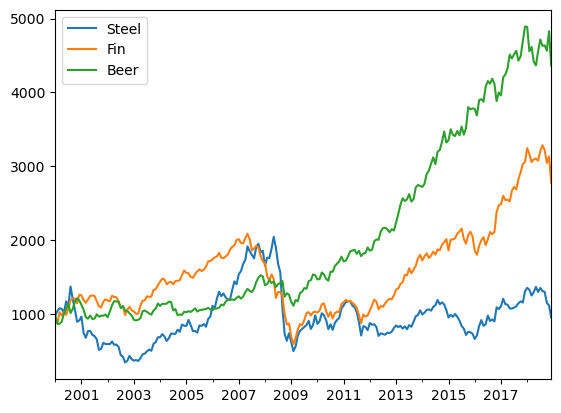

In [17]:
risky_wealth = start * (1 + risky_r).cumprod()
risky_wealth.plot()

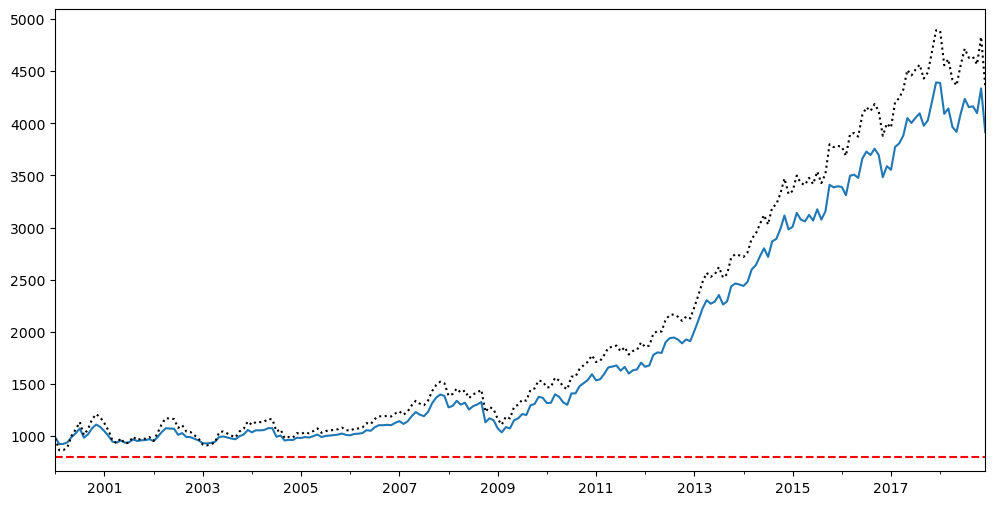

In [19]:
ax = account_history['Beer'].plot(figsize = (12, 6))
risky_wealth['Beer'].plot(ax = ax, style = 'k:')
ax.axhline(y = floor_val, color = 'r', linestyle = '--')

<Axes: >

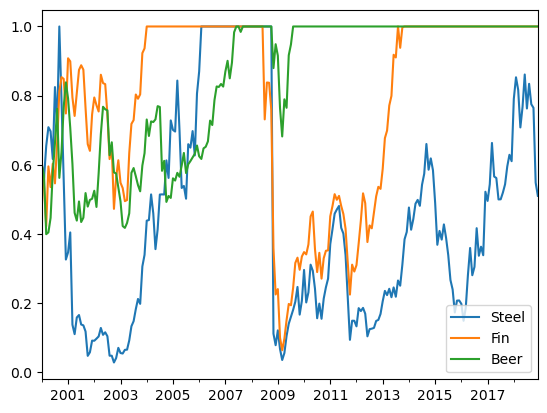

In [21]:
risky_w_history.plot()

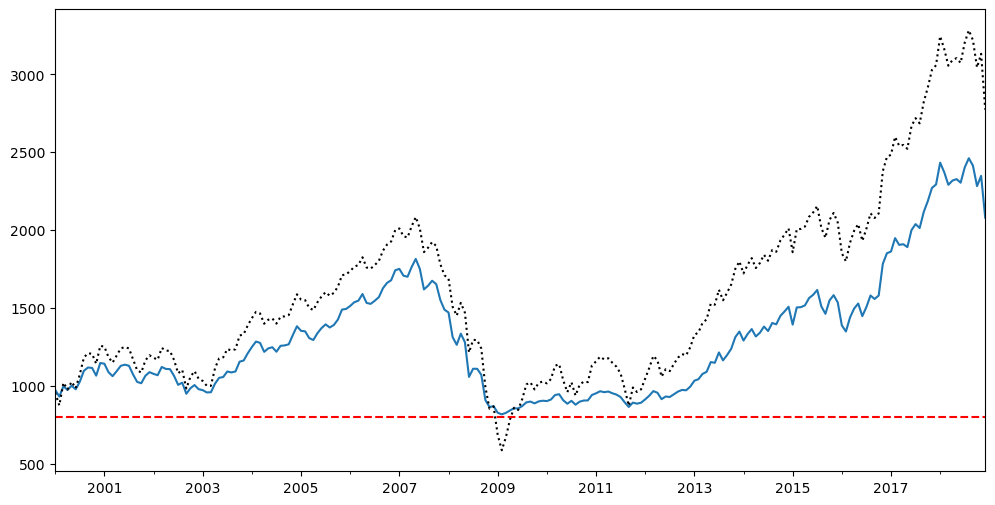

In [22]:
ind = 'Fin'
ax = account_history[ind].plot(figsize = (12, 6))
risky_wealth[ind].plot(ax = ax, style = 'k:')
ax.axhline(y = floor_val, color = 'r', linestyle = '--')

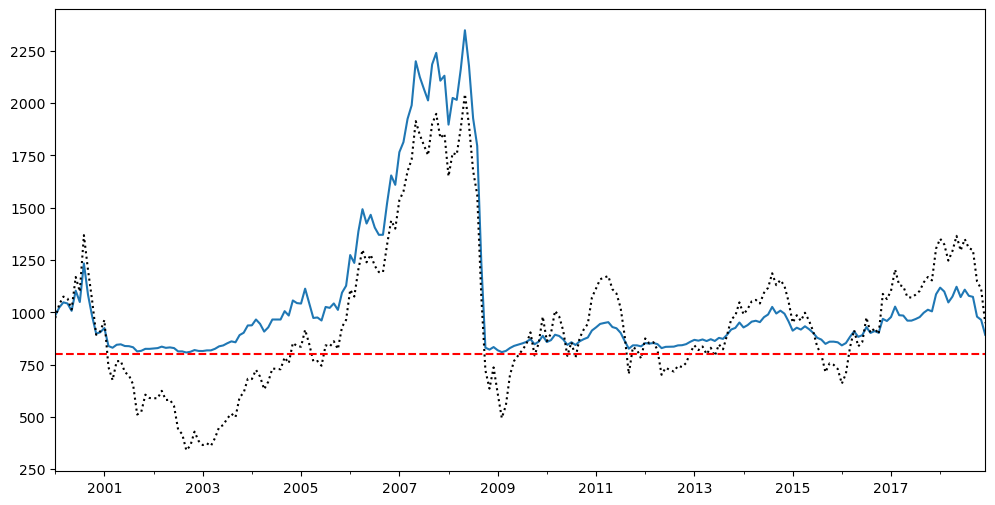

In [23]:
ind = 'Steel'
ax = account_history[ind].plot(figsize = (12, 6))
risky_wealth[ind].plot(ax = ax, style = 'k:')
ax.axhline(y = floor_val, color = 'r', linestyle = '--')

In [25]:
rk.summary_stats(risky_r)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Steel,-0.002790,0.312368,-0.326334,4.144381,0.150139,0.208117,-0.102567,-0.758017
Fin,0.055166,0.192909,-0.533218,4.995534,0.091224,0.132175,0.126718,-0.718465
Beer,0.080598,0.138925,-0.493545,4.173881,0.063015,0.091442,0.354314,-0.271368


In [26]:
btr = rk.run_cppi(risky_r)
rk.summary_stats(btr['Wealth'].pct_change().dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Steel,-0.005167,0.174180,-1.995143,17.110190,0.091995,0.130153,-0.196750,-0.655198
Fin,0.040894,0.131678,-0.946504,6.051414,0.065535,0.091621,0.080352,-0.549673
Beer,0.075544,0.115462,-0.669250,4.760879,0.052923,0.074908,0.383772,-0.259582


<Axes: >

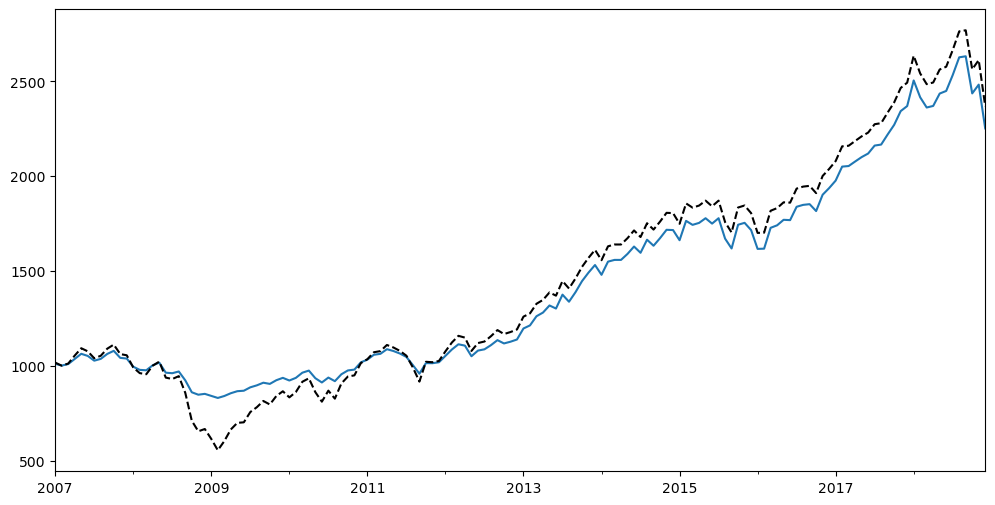

In [28]:
btr = rk.run_cppi(tmi_return.loc['2007':])
ax = btr['Wealth'].plot(figsize = (12, 6), legend = False)
btr['Risky Wealth'].plot(ax = ax, style = 'k--', legend = False)

In [29]:
rk.summary_stats(btr['Risky Wealth'].pct_change().dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
R,0.073411,0.150463,-0.734939,4.523488,0.071592,0.096315,0.280618,-0.499943


In [30]:
rk.summary_stats(btr['Wealth'].pct_change().dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
R,0.069416,0.100381,-0.588292,3.740932,0.045678,0.062953,0.382052,-0.229683


## Drawdown Constraint

In [36]:
btr = rk.run_cppi(ind_rets.loc['2007':][['Steel', 'Fin', 'Beer']], drawdown = 0.25)

<Axes: >

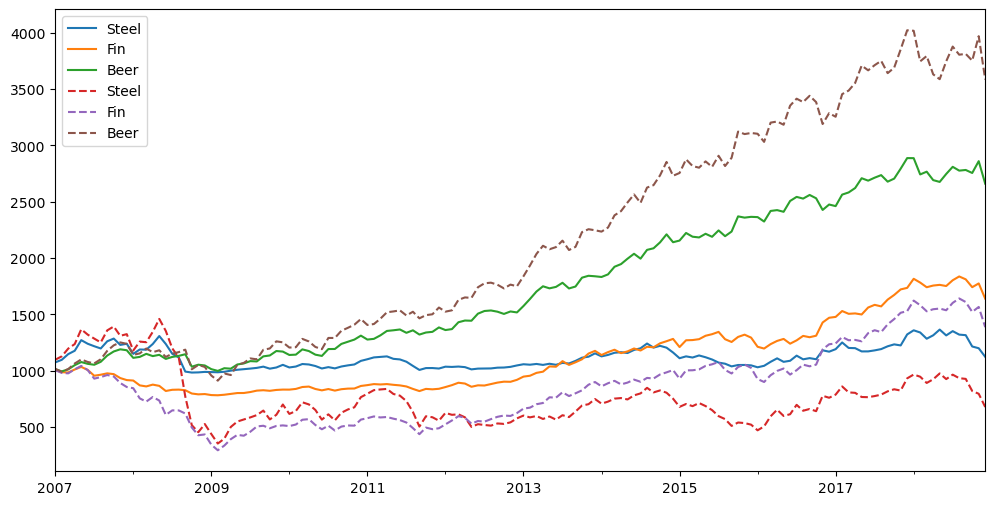

In [37]:
ax = btr['Wealth'].plot(figsize = (12, 6))
btr['Risky Wealth'].plot(ax = ax, style = '--')

In [39]:
rk.summary_stats(btr['Risky Wealth'].pct_change().dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Steel,-0.039660,0.306407,-0.459951,4.782828,0.152288,0.203837,-0.221642,-0.758017
Fin,0.027364,0.212204,-0.695200,4.621401,0.105744,0.149862,-0.012370,-0.718465
Beer,0.111554,0.127971,-0.670797,4.650878,0.056497,0.077388,0.620132,-0.271368


In [40]:
rk.summary_stats(btr['Wealth'].pct_change().dropna())

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Steel,0.003784,0.097073,-0.441089,5.220481,0.047371,0.066991,-0.262958,-0.248059
Fin,0.041975,0.085028,-0.355163,4.153860,0.038342,0.054111,0.136964,-0.243626
Beer,0.084375,0.086263,-0.744111,4.571533,0.037937,0.051189,0.613413,-0.161186
